In [1]:
import pandas as pd
import numpy as np


In [7]:
df = pd.read_csv("../data/processed/operations_cleaned.csv")

In [48]:
site_id = "SITE_002"
site_df = df[df['site_id']==site_id].copy()

In [49]:
# this is to sort the table based on date
site_df.set_index('date',inplace=True)
site_df= site_df.sort_index()

In [50]:
df

,date,site_id,region,behavior,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity,capacity_violation,opening_overflow_tonnes,closing_overflow_tonnes
0,2022-01-01,SITE_001,North,aggressive,CEM_II,43.18,34.54,52.56,45.83,63.85,3.40,-3.10,448,False,0.0,0.0
1,2022-01-02,SITE_001,North,aggressive,CEM_I,45.26,45.26,63.85,19.97,38.56,3.23,14.28,448,False,0.0,0.0
2,2022-01-03,SITE_001,North,aggressive,CEM_III,38.69,38.69,38.56,47.19,47.06,2.64,6.40,448,False,0.0,0.0
3,2022-01-04,SITE_001,North,aggressive,CEM_I,33.16,33.16,47.06,18.74,32.64,8.25,14.23,448,False,0.0,0.0
4,2022-01-05,SITE_001,North,aggressive,CEM_III,56.88,47.04,32.64,14.40,0.00,2.69,8.97,448,False,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32875,2024-12-27,SITE_030,South,aggressive,CEM_III,58.48,29.63,0.00,29.63,0.00,7.17,12.00,316,False,0.0,0.0
32876,2024-12-28,SITE_030,South,aggressive,CEM_I,45.39,22.35,0.00,22.35,0.00,2.13,8.04,316,False,0.0,0.0
32877,2024-12-29,SITE_030,South,aggressive,CEM_III,58.47,14.21,0.00,14.21,0.00,0.28,2.26,316,False,0.0,0.0
32878,2024-12-30,SITE_030,South,aggressive,CEM_II,59.58,10.65,0.00,10.65,0.00,4.58,9.55,316,False,0.0,0.0


In [51]:
y=site_df['consumed_tonnes']
exog = site_df[['planned_pour_tonnes', 'opening_inventory_tonnes', 'deliveries_tonnes'	, 'closing_inventory_tonnes'		, 'rain_mm'	, 'avg_temp_c'	, 'silo_capacity'	]]

# Checkking for seasonality

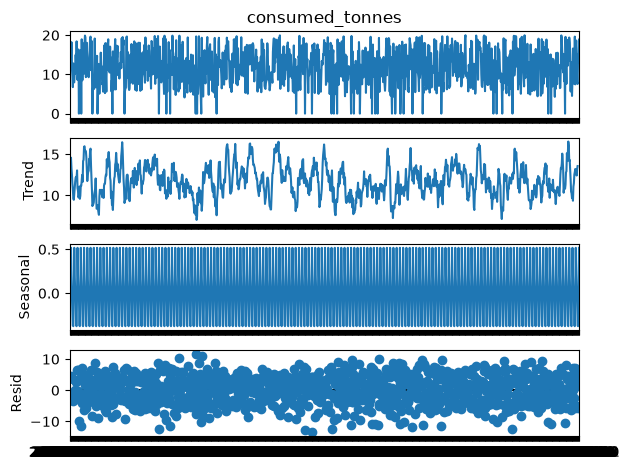

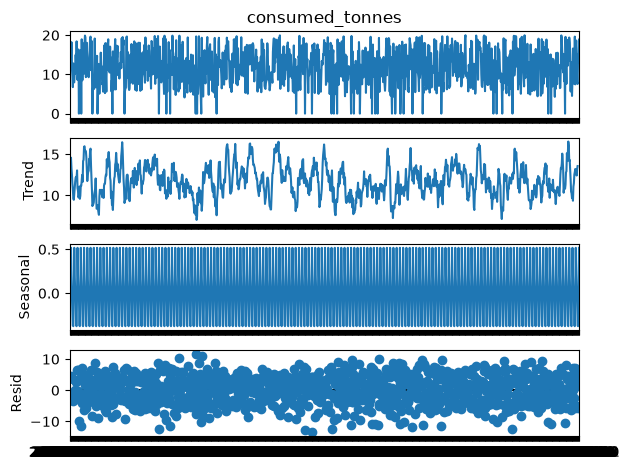

In [52]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(y, model = 'additive', period=7)
decomp.plot()

Training SARIMAX Model


In [53]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


# Splitting DATA
split_index = int(len(site_df)*0.8)

x_train, x_test = exog.iloc[:split_index], exog.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [54]:
x_train

,planned_pour_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
date,,,,,,,
2022-01-01,15.70,28.46,12.12,24.87,3.31,4.86,288
2022-01-02,18.22,24.87,34.31,40.96,7.03,5.79,288
2022-01-03,15.46,40.96,25.46,50.96,2.58,5.30,288
2022-01-04,13.25,50.96,16.78,54.49,2.73,13.39,288
2022-01-05,18.23,54.49,39.58,75.84,5.06,9.88,288
...,...,...,...,...,...,...,...
2024-05-21,6.42,15865.79,39.57,15898.94,6.51,11.11,288
2024-05-22,5.08,15898.94,17.32,15911.18,5.39,14.36,288
2024-05-23,6.02,15911.18,49.89,15955.05,3.18,9.01,288


In [55]:
order=(1,1,1)
seasonal_order=(1,0,1,7)

In [56]:
model = SARIMAX(
    y_train,
    exog=x_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False

)

results =model.fit()
results.summary()

c:\Users\gideo\OneDrive\Desktop\ADMARI\Admari 2\Cement demand forcasting\Cement-Demand-Forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\gideo\OneDrive\Desktop\ADMARI\Admari 2\Cement demand forcasting\Cement-Demand-Forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\gideo\OneDrive\Desktop\ADMARI\Admari 2\Cement demand forcasting\Cement-Demand-Forecasting\venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                   consumed_tonnes   No. Observations:                  876
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood                8453.469
Date:                           Fri, 07 Aug 2026   AIC                         -16882.939
Time:                                   19:10:30   BIC                         -16825.772
Sample:                               01-01-2022   HQIC                        -16861.061
                                    - 05-25-2024                                         
Covariance Type:                             opg                                         
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
planned_pour_tonnes       6.168e-07      7e-07      0.881      0.378   -7.56e-07    1.99e-06
opening_inventory_tonnes     1.0000   7.16e-07    1.4e+06      0.000       1.000       1.000
deliveries_tonnes            1.0000   7.18e-07   1.39e+06      0.000       1.000       1.000
closing_inventory_tonnes    -1.0000   7.15e-07   -1.4e+06      0.000      -1.000      -1.000
rain_mm                   1.206e-06   1.03e-07     11.663      0.000       1e-06    1.41e-06
avg_temp_c                2.008e-07   1.04e-07      1.926      0.054   -3.54e-09    4.05e-07
silo_capacity             7.521e-22         -0       -inf      0.000    7.52e-22    7.52e-22
ar.L1                       -0.0871   1.47e-12  -5.94e+10      0.000      -0.087      -0.087
ma.L1                       -0.4650   1.94e-12   -2.4e+11      0.000      -0.465      -0.465
ar.S.L7                      0.0951   4.46e-12   2.13e+10      0.000       0.095       0.095
ma.S.L7                     -0.0455   4.19e-12  -1.09e+10      0.000      -0.045      -0.045
sigma2                    2.362e-10   9.22e-11      2.560      0.010    5.54e-11    4.17e-10
===================================================================================
Ljung-Box (L1) (Q):                  40.84   Jarque-Bera (JB):                 4.87
Prob(Q):                              0.00   Prob(JB):                         0.09
Heteroskedasticity (H):               1.16   Skew:                            -0.08
Prob(H) (two-sided):                  0.21   Kurtosis:                         2.67
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.86e+30. Standard errors may be unstable.
"""

In [57]:
y_pred = results.predict(start=y_test.index[0], end=y_test.index[-1], exog=x_test)

In [58]:
from sklearn.metrics import mean_absolute_percentage_error , root_mean_squared_error

MAPE = mean_absolute_percentage_error(y_test,y_pred)
print(f"MAPE = {MAPE}")

RMSE = root_mean_squared_error(y_test,y_pred)
print(f"RMSE= {RMSE}")

MAPE = 9489892018.372635
RMSE= 6.309666022468426e-05


In [33]:
metrics = {RMSE, MAPE}

In [59]:
import mlflow
import mlflow.statsmodels
from mlflow.models.signature import infer_signature
import numpy as np
#from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
# 1. Set tracking URI & Experiment
mlflow.set_tracking_uri("sqlite:///mlflow.db")  # or "sqlite:///mlflow.db"
mlflow.set_experiment("Cement Demand SARIMAX Forecasting")
# 2. Log run after training
with mlflow.start_run(run_name=f"SARIMAX_{site_id}"):
    """
    # Track Parameters
    mlflow.log_params({
        "site_id": site_id,
        "target_col": y,
        "exog_cols": str(x_train),
        "order": str(order),
        "seasonal_order": str(seasonal_order),
        "train_size": len(y_train),
        "test_size": len(y_test)
    })
    """
    # Calculate & Log Metrics (RMSE, MAE, Zero-Safe MAPE, AIC, BIC)
    
    mlflow.log_metrics({
        "RMSE": RMSE,
        "MAPE": MAPE
        
    })
    # Set Tag
    mlflow.set_tag("training_information", f"SARIMAX Model for {site_id}")
    # Log Model (using mlflow.statsmodels flavor)
    signature = infer_signature(x_train, y_train)
    mlflow.statsmodels.log_model(
        statsmodels_model=results,
        name=f"sarimax_model_{site_id}",
        signature=signature,
        
    )

c:\Users\gideo\OneDrive\Desktop\ADMARI\Admari 2\Cement demand forcasting\Cement-Demand-Forecasting\venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


In [ ]:
# ----------------------------------------------------
    # SET TAGS
    # ----------------------------------------------------
mlflow.set_tag("training_information", f"SARIMAX Time Series Model for {site_id}")
mlflow.set_tag("model_type", "SARIMAX")

In [ ]:
import mlflow

# After the server is runningn, set the tracking URI to point to the server. This is where MLflow will log all the experiments and runs.
mlflow.set_tracking_uri("http://127.0.0.1:5000") # this could be a remote url

mlflow.set_experiment("Customer churn")

with mlflow.start_run():
    # track parameters

    # log metrics
    mlflow.log_metrics({"RMSE":RMSE, "MAPE":MAPE})

    # Setting a tag for this traing run 
    mlflow.set_tag("training information", "Radomforest model")

    # log model
    signature= infer_signature(X_train,rf_model.predict(X_train))
    model_info= mlflow.sklearn.log_model(
        sk_model=rf_model,
        name="Customer Churn RF",
        signature=signature,
        input_example=X_train
    )


